In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Reproducibility
np.random.seed(42)

# Create Taxi env with text rendering
env = gym.make("Taxi-v3", render_mode="ansi")

print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)


Number of states: 500
Number of actions: 6


In [2]:
def reset_env(env):
    """Reset env and return only state id."""
    obs, info = env.reset()
    return obs

def step_env(env, action):
    """Step env, unify terminated+truncated → done."""
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    return obs, reward, done, info

def render_env(env):
    """Print ASCII grid."""
    print(env.render())


In [ ]:
action_meaning = {
    0: "South",
    1: "North",
    2: "East",
    3: "West",
    4: "Pickup",
    5: "Dropoff",
}

for a in range(env.action_space.n):
    print(a, "-", action_meaning[a])


In [4]:
def train_q_learning(env,
                     num_episodes=5000,
                     max_steps=200,
                     alpha=0.1,
                     gamma=0.99,
                     epsilon_start=1.0,
                     epsilon_decay=0.995,
                     min_epsilon=0.01):
    """
    Generic Q-learning trainer. We'll call this twice:
    - once for Model A (baseline)
    - once for Model B (optimised)
    """
    state_space_size  = env.observation_space.n
    action_space_size = env.action_space.n

    Q = np.zeros((state_space_size, action_space_size))
    epsilon = epsilon_start
    rewards = []

    for ep in range(num_episodes):
        state = reset_env(env)
        done = False
        total_reward = 0

        for step in range(max_steps):
            # ε-greedy
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            next_state, reward, done, info = step_env(env, action)

            # Q-update
            old_value = Q[state, action]
            next_max  = np.max(Q[next_state])

            target = reward + gamma * next_max
            Q[state, action] = old_value + alpha * (target - old_value)

            state = next_state
            total_reward += reward

            if done:
                break

        # decay epsilon
        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        rewards.append(total_reward)

        if (ep + 1) % 500 == 0:
            print(
                f"Episode {ep+1}/{num_episodes} | "
                f"Total reward: {total_reward} | "
                f"Epsilon: {epsilon:.3f}"
            )

    return Q, rewards


def evaluate_agent(env, Q, episodes=200, max_steps=200):
    """Greedy evaluation of a trained Q-table."""
    rewards = []
    steps_list = []

    for ep in range(episodes):
        state = reset_env(env)
        done = False
        total_reward = 0
        steps = 0

        for step in range(max_steps):
            action = np.argmax(Q[state])
            state, reward, done, info = step_env(env, action)
            total_reward += reward
            steps += 1
            if done:
                break

        rewards.append(total_reward)
        steps_list.append(steps)

    return rewards, steps_list


In [5]:
# Shared hyperparameters
num_episodes = 5000
max_steps    = 200

alpha = 0.1
gamma = 0.99

epsilon_start = 1.0
min_epsilon   = 0.01

epsilon_decay_A = 0.995   # baseline
epsilon_decay_B = 0.99    # "optimised" (faster decay)


Training Model A (epsilon_decay = 0.995)...
Episode 500/5000 | Total reward: -189 | Epsilon: 0.082
Episode 1000/5000 | Total reward: 6 | Epsilon: 0.010
Episode 1500/5000 | Total reward: 6 | Epsilon: 0.010
Episode 2000/5000 | Total reward: 5 | Epsilon: 0.010
Episode 2500/5000 | Total reward: 8 | Epsilon: 0.010
Episode 3000/5000 | Total reward: 7 | Epsilon: 0.010
Episode 3500/5000 | Total reward: 11 | Epsilon: 0.010
Episode 4000/5000 | Total reward: 10 | Epsilon: 0.010
Episode 4500/5000 | Total reward: 9 | Epsilon: 0.010
Episode 5000/5000 | Total reward: 5 | Epsilon: 0.010
Model A - average reward over last 100 episodes: 7.93


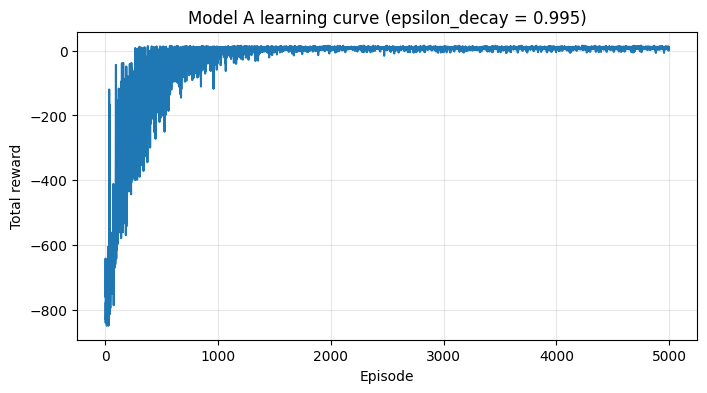

In [13]:
print("Training Model A (epsilon_decay = 0.995)...")
Q_A, rewards_A = train_q_learning(
    env,
    num_episodes=num_episodes,
    max_steps=max_steps,
    alpha=alpha,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_decay=epsilon_decay_A,
    min_epsilon=min_epsilon,
)

print("Model A - average reward over last 100 episodes:",
      np.mean(rewards_A[-100:]))

plt.figure(figsize=(8, 4))
plt.plot(rewards_A)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Model A learning curve (epsilon_decay = 0.995)")
plt.grid(True, alpha=0.3)
plt.show()


Training Model B (epsilon_decay = 0.99)...
Episode 500/5000 | Total reward: -57 | Epsilon: 0.010
Episode 1000/5000 | Total reward: 7 | Epsilon: 0.010
Episode 1500/5000 | Total reward: 6 | Epsilon: 0.010
Episode 2000/5000 | Total reward: 9 | Epsilon: 0.010
Episode 2500/5000 | Total reward: 5 | Epsilon: 0.010
Episode 3000/5000 | Total reward: 9 | Epsilon: 0.010
Episode 3500/5000 | Total reward: 8 | Epsilon: 0.010
Episode 4000/5000 | Total reward: 6 | Epsilon: 0.010
Episode 4500/5000 | Total reward: 8 | Epsilon: 0.010
Episode 5000/5000 | Total reward: 4 | Epsilon: 0.010
Model B - average reward over last 100 episodes: 7.22


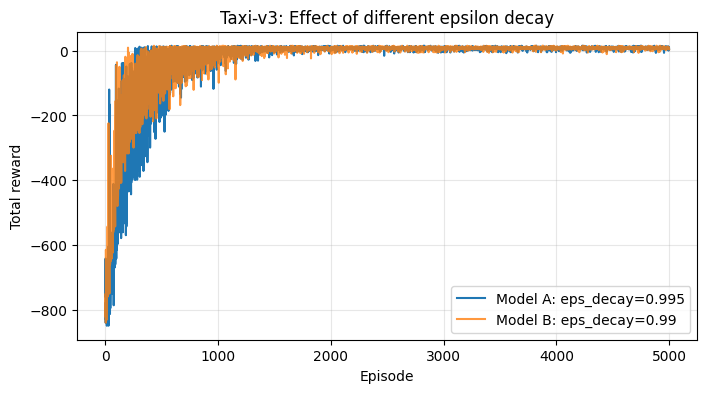

In [14]:
print("Training Model B (epsilon_decay = 0.99)...")
Q_B, rewards_B = train_q_learning(
    env,
    num_episodes=num_episodes,
    max_steps=max_steps,
    alpha=alpha,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_decay=epsilon_decay_B,
    min_epsilon=min_epsilon,
)

print("Model B - average reward over last 100 episodes:",
      np.mean(rewards_B[-100:]))

plt.figure(figsize=(8, 4))
plt.plot(rewards_A, label="Model A: eps_decay=0.995")
plt.plot(rewards_B, label="Model B: eps_decay=0.99", alpha=0.8)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Taxi-v3: Effect of different epsilon decay")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [16]:
greedy_rewards_A, greedy_steps_A = evaluate_agent(env, Q_A, episodes=3000)
greedy_rewards_B, greedy_steps_B = evaluate_agent(env, Q_B, episodes=3000)

print("=== Greedy Evaluation over 3000 episodes ===")
print("Model A (eps_decay=0.995):")
print("  Avg reward:", np.mean(greedy_rewards_A))
print("  Avg steps :", np.mean(greedy_steps_A))
print("  Max reward:", np.max(greedy_rewards_A))
print("  Max steps :", np.max(greedy_steps_A))
print("  Min reward:", np.min(greedy_rewards_A))
print("  Min steps :", np.min(greedy_steps_A))

print("\nModel B (eps_decay=0.99):")
print("  Avg reward:", np.mean(greedy_rewards_B))
print("  Avg steps :", np.mean(greedy_steps_B))
print("  Max reward:", np.max(greedy_rewards_B))
print("  Max steps :", np.max(greedy_steps_B))
print("  Min reward:", np.min(greedy_rewards_B))
print("  Min steps :", np.min(greedy_steps_B))


=== Greedy Evaluation over 3000 episodes ===
Model A (eps_decay=0.995):
  Avg reward: 7.918666666666667
  Avg steps : 13.081333333333333
  Max reward: 15
  Max steps : 18
  Min reward: 3
  Min steps : 6

Model B (eps_decay=0.99):
  Avg reward: 7.929333333333333
  Avg steps : 13.070666666666666
  Max reward: 15
  Max steps : 18
  Min reward: 3
  Min steps : 6
